# Intersect Community Data Workflow for Seaside, OR (Test case)
Use this notebook to test that pyncoda is working correctly. Seaside is in Clatsop County OR, which is a small example to run on a local computer. Recent runs took around 15 minutes to complete.

## Overview
This code works with the National Structures Inventory to run the housing unit allocation (HUA) and the person record file (PREC) workflow.

Functions are provided to obtain and clean data required for the version 2.2.0 Housing Unit Allocation. 

## Required Inputs
Program requires the following inputs:
If using the National Structures Inventory there are no required inputs.

[Census API KEY *REQUIRED*](CENSUS_API_KEY.md) See CENSUS_API_KEY.md file for more details.
    
## Output Description
The output of this workflow is a CSV file with the housing unit inventory allocated to a building inventory using the housing unit allocation model.

The output CSV is designed to be used in the Interdependent Networked Community Resilience Modeling Environment (IN-CORE).

IN-CORE is an open source python package that can be used to model the resilience of a community. To download IN-CORE, see:

https://incore.ncsa.illinois.edu/


## Instructions
Users can run the workflow by executing each block of code in the notebook.

## Description of Program
- program:    ncoda_07jv3_HUA_NSI_Hayward
- task:       Start with NSI building inventory, run housing unit allocation algorithm, and then run person record file algorithm
- See github commits for description of program updates
- Current Version: v3 - 
- 2024-02-20 - Combine code from 07c, 07d, and 07e into one notebook
- 2024-05-22 - removed the drop down menu, did not work consistently
- 2025-02-21 - Test with 2020 HUI
- 2025-03-07 - Update to version 2 to differentiate running 2010 and 2020
- 2025-03-27 - V3 Solved issue for states starting with 0 FIPS code - major modification to code
- 2025-09-17 - Adjust code to run a Monte Carlo Simulation
- 2026-04-16 - Running code to explore missing building data
- 2026-05-23 - v2.1.0 PR 136 change to address point prediction
             - Census API Key NOW REQUIRED
- project:    Interdependent Networked Community Resilience Modeling Environment (IN-CORE), Subtask 5.2 - Social Institutions
- funding:	  NIST Financial Assistance Award Numbers: 70NANB15H044 and 70NANB20H008
- funding:	  Southeast Texas Urban Integrated Field Lab Department of Energy DE-SC0023216 
- author:     Nathanael Rosenheim

## Required Citations:
Rosenheim, Nathanael, Roberto Guidotti, Paolo Gardoni & Walter Gillis Peacock. (2021). Integration of detailed household and housing unit characteristic data with critical infrastructure for post-hazard resilience modeling. _Sustainable and Resilient Infrastructure_. 6(6), 385-401. https://doi.org/10.1080/23789689.2019.1681821

Rosenheim, Nathanael (2021) “Detailed Household and Housing Unit Characteristics: Data and Replication Code.” _DesignSafe-CI_. 
https://doi.org/10.17603/ds2-jwf6-s535.

In [1]:
# To reload submodules need to use this magic command to set autoreload on
%load_ext autoreload
%autoreload 2
from pyncoda.ncoda_00g_community_options import *
from IPython.display import display

### How to set up the Community Dictionary
Please review the python code in the file pyncoda/ncoda_00g_community_options.py

In this file you will find a collection of data dictionaries with various ways to setup the inputs for the Housing Unit Allocation process. 

The basic dictionary includes the name of the community, the county FIPS code, your input building inventory file, and key variables in the building inventory file.

In [2]:
# select a community from this list
# if your community is not in this list, add it to the file ncoda_00g_community_options.py
list_community_options(communities_dictionary)

['Lumberton, NC: IN-CORE Building inventory for Robeson County, NC',
 'Galveston, TX: IN-CORE Building inventory for Galveston County, TX',
 'Galveston, TX: NSI Building inventory for Galveston County, TX',
 'Galveston, TX: IN-CORE Building inventory for Galveston Island, TX',
 'Mayfield, KY: NSI Building inventory for Graves County, KY',
 'Beaumont, TX: NSI Building inventory for Jefferson County, TX',
 'Beaumont, TX: Safayet Building inventory for Jefferson County, TX',
 'Pentwater, MI: NSI Building inventory for Oceana County, MI',
 'Seaside, OR: NSI Building inventory for Clatsop County, OR',
 'Lane County, OR: NSI Building inventory for Lane County, OR',
 'Benton County, OR: NSI Building inventory for Benton County, OR',
 'Southeast Texas Urban Integrated Field Lab: NSI Building inventory for Southeast Texas',
 'Southeast Texas Urban Integrated Field Lab (12 neighbor counties): NSI Building inventory for Southeast Texas',
 'Brazos County, TX: NSI Building inventory for Brazos Coun

In [3]:
community_id_by_name =  'Seaside, OR: NSI Building inventory for Clatsop County, OR'

In [4]:
community_id, focalplace, countyname, countyfips = get_community_id_by_name(community_id_by_name)
communities = {community_id : communities_dictionary[community_id]}

Selected community ID: Seaside_OR_NSI
Seaside, OR is in OREGON
Focal place: Seaside
Seaside, OR is in Clatsop County, OR with FIPS code 41007
Use IN-CORE: False


## Setup Python Environment

In [5]:
import pandas as pd
import geopandas as gpd # For reading in shapefiles
import numpy as np
import sys # For displaying package versions
import os # For managing directories and file paths if drive is mounted
import scooby # Reports Python environment

import contextily as cx # For adding basemap tiles to plot
import matplotlib.pyplot as plt # For plotting and making graphs

In [6]:
# open, read, and execute python program with reusable commands
from pyncoda.ncoda_00d_cleanvarsutils import *
from pyncoda.ncoda_04c_poptableresults import *
from pyncoda.ncoda_07i_process_communities import process_community_workflow

In [7]:
# Generate report of Python environment
base_packages = ['pandas','ipyleaflet','seaborn','contextily']
incore_packages = ['pyincore','pyincore_viz']
check_packages = base_packages + incore_packages
print(scooby.Report(additional=check_packages))


--------------------------------------------------------------------------------
  Date: Tue Sep 01 10:34:03 2026 Eastern Daylight Time

                OS : Windows (10 10.0.26200 SP0 Multiprocessor Free)
            CPU(s) : 16
           Machine : AMD64
      Architecture : 64bit
               RAM : 31.7 GiB
       Environment : Jupyter

  Python 3.10.14 | packaged by Anaconda, Inc. | (main, May  6 2024, 19:44:50)
  [MSC v.1916 64 bit (AMD64)]

            pandas : 2.2.2
        ipyleaflet : Module not found
           seaborn : 0.13.2
        contextily : 1.6.0
          pyincore : Module not found
      pyincore_viz : Module not found
             numpy : 1.26.4
             scipy : 1.13.1
           IPython : 8.25.0
        matplotlib : 3.8.4
            scooby : 0.10.0

  Intel(R) oneAPI Math Kernel Library Version 2023.1-Product Build 20230303
  for Intel(R) 64 architecture applications
--------------------------------------------------------------------------------


In [8]:
# Check working directory - good practice for relative path access
os.getcwd()

'c:\\Users\\nathanael99\\MyProjects\\GitHub\\intersect-community-data'

## Run Housing Unit Allocation
The following code will produce the following outputs:
1. Housing Unit Inventory
2. Address Point Inventory
3. Housing Unit Allocation

In [9]:
basevintage_options = ['2010','2020']

Running iteration 1 of 1 for basevintage 2010 with seed 9876
Creating folder OutputData/Seaside_OR_NSI to store output.
Creating folder OutputData/Seaside_OR_NSI/00_logfiles
     logfiles Folder purpose: Store text files with log of workflow.
Creating folder OutputData/Seaside_OR_NSI/01_CommunitySourceData
     CommunitySourceData Folder purpose: Source source data files. Helps with software development and replication.
Creating folder OutputData/Seaside_OR_NSI/02_TidyCommunitySourceData
     TidyCommunitySourceData Folder purpose: Cleaned source data and inputs for base inventory.
Creating folder OutputData/Seaside_OR_NSI/03_BaseInventory
     BaseInventory Folder purpose: Initial inventories before random merge. Use as inputs to uncertainty propagation.
Creating folder OutputData/Seaside_OR_NSI/04_RandomMerge
     RandomMerge Folder purpose: Results of random merge with flag columns.
Creating folder OutputData/Seaside_OR_NSI/05_Verify
     Verify Folder purpose: Results to compare in

c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:475: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged_groups[self.new_char] = merged_groups[self.new_char].\
c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:765: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = .5


Primary data frame has extra family  observations with no match: 6167
Observations with no match filled with 0
Merge found extra family  observations: 142
    Set Flags after Merge
['uniqueidB19001', 'Tract2010', 'race', 'hispan', 'incomegroup', 'random_mergeorder', 'uniqueidB19101', 'family', 'check_merge', 'family_flagsetrm', 'family_Tract2010_flagsetrm']
Observations without primary flag set 16158
Observations without geovar flag set 16158
After updated observations without geovar flag set 16158
Round = 1
Setting 9849 flags for observations set by random merge using both primary and secondary data.
Setting 0 flags for observations set by random merge using only primary data.
0 observations do not have required variable Tract2010
0 observations do not have required variable race
0 observations do not have required variable hispan
0 observations do not have required variable incomegroup
0 observations do not have required variable race
0 observations do not have required variable hisp

c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:475: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged_groups[self.new_char] = merged_groups[self.new_char].\
c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:475: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged_groups[self.new_char] = merged_groups[self.new_char].\


Merge found extra incomegroup  observations: 213
    Set Flags after Merge
['huid', 'Tract2010', 'hispan', 'family', 'random_mergeorder', 'uniqueidB19001', 'incomegroup', 'family_flagsetrm', 'family_Tract2010_flagsetrm', 'family_County2010_flagsetrm', 'check_merge', 'incomegroup_flagsetrm', 'incomegroup_Tract2010_flagsetrm']
Observations without primary flag set 914
Observations without geovar flag set 914
After updated observations without geovar flag set 914
Round = 1
Setting 558 flags for observations set by random merge using both primary and secondary data.
Setting 0 flags for observations set by random merge using only primary data.
0 observations do not have required variable Tract2010
0 observations do not have required variable hispan
0 observations do not have required variable family
0 observations do not have required variable hispan
Setting 0 flags for observations without required variable Tract2010
Setting 0 flags for observations without required variable hispan
Setting

...

EPSG 4269 is the current projection
Spatially Join place Columns ['GEOID', 'NAME', 'NAMELSAD'] with Block Data.
Polygon file has 426 place polygons.
Identified 10 place polygons to spatially join.
Spatially Join puma Columns ['GEOID20', 'NAMELSAD20'] with Block Data.
Polygon file has 35 puma polygons.
Identified 2 puma polygons to spatially join.
Checking Column Names for ['GEOID', 'NAME', 'NAMELSAD'] in puma data
Column GEOID is not correctly formatted
Changing column name to placeGEOID20
Column NAME is not correctly formatted
Changing column name to placeNAME20
Column NAMELSAD is not correctly formatted
Changing column name to placeNAMELSAD20
Column GEOID is correctly formatted
Column NAME is not correctly formatted
Column name should be pumaNAME20
Please check column names in puma data
Column NAMELSAD is correctly formatted
***************
Predicting Housing Unit Estimates
***************

Dropping observations where geometry is null
Number of observations dropped:  0
Building Inven

c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\ncoda_00e_geoutilities.py:310: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4110850' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  copy_point_gdf.loc[precise_matches.index,geolevel+col] = polygon[col]
c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\ncoda_00e_geoutilities.py:310: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Cannon Beach' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  copy_point_gdf.loc[precise_matches.index,geolevel+col] = polygon[col]


.....................Using residential archetypes for residential unit estimates
1310 Buildings have Residential Archetype RES1-1SNB
10703 Buildings have Residential Archetype RES1-1SWB
412 Buildings have Residential Archetype RES1-2SNB
4962 Buildings have Residential Archetype RES1-2SWB
17 Buildings have Residential Archetype RES1-3SNB
41 Buildings have Residential Archetype RES1-3SWB
0 Buildings have Residential Archetype RES1-SLNB
0 Buildings have Residential Archetype RES1-SLWB
0 Buildings have Residential Archetype RES1
1443 Buildings have Residential Archetype RES2
2418 Buildings have Residential Archetype RES3A
308 Buildings have Residential Archetype RES3B
182 Buildings have Residential Archetype RES3C
59 Buildings have Residential Archetype RES3D
16 Buildings have Residential Archetype RES3E
5 Buildings have Residential Archetype RES3F
306 Buildings have Residential Archetype RES4
3 Buildings have Residential Archetype RES5
14 Buildings have Residential Archetype RES6
158 Buil

c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\ncoda_07d_run_hua_workflow.py:173: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1

Primary key variable huid is unique.
Primary key huid has no missing values
['huid', 'Block2020', 'blockid', 'bgid', 'tractid', 'FIPScounty', 'numprec', 'ownershp', 'race', 'hispan', 'family', 'vacancy', 'gqtype', 'incomegroup', 'hhinc', 'randincome', 'poverty', 'BLOCKID20_str', 'huicounter1', 'huicounter2', 'huicounter3', 'ownershp1', 'ownershp2', 'ownershp3', 'strctid', 'strctid_flagsetrm', 'strctid_Block2020_flagsetrm', 'addrptid', 'fd_id_bid', 'huestimate', 'huicounter_addpt', 'placeNAME20', 'x', 'y']
Observations without primary flag set 7224
Observations without geovar flag set 7224
After updated observations without geovar flag set 7224
Setting 0 flags for strctid set before random merge.
0 observations do not have required variable Block2020
0 observations do not have required variable huicounter3
0 observations do not have required variable ownershp1
Setting 0 flags for observations without required variable Block2020
Setting 0 flags for observations without required variable 

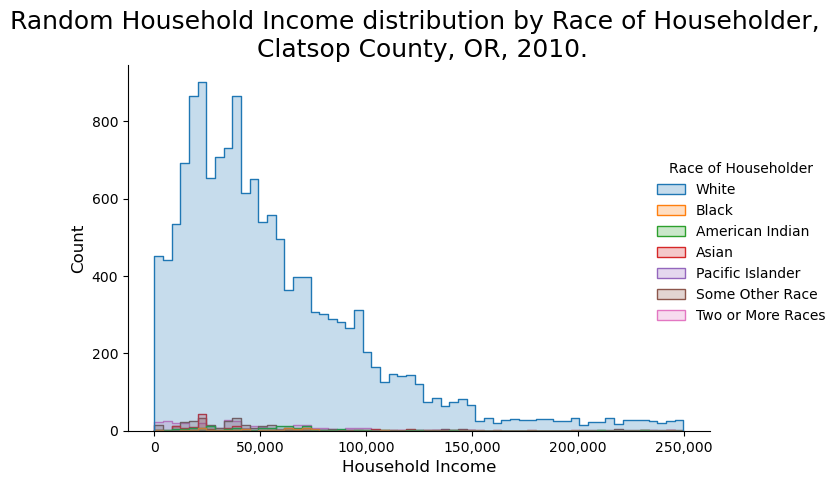

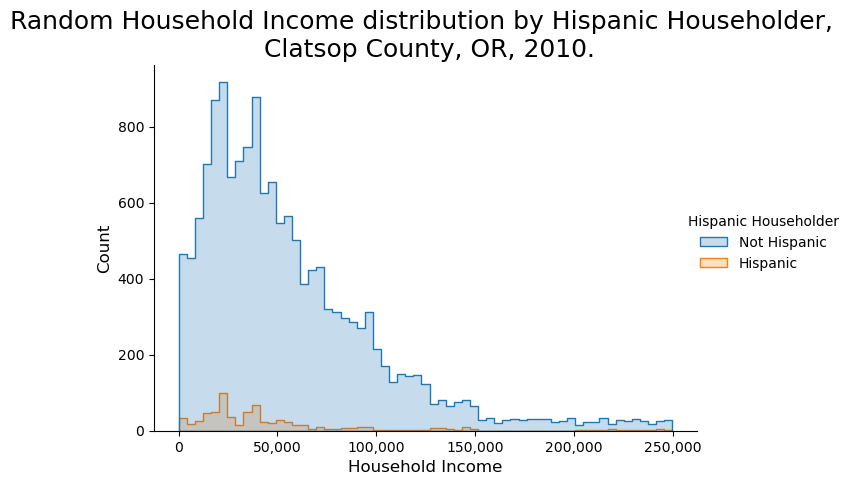

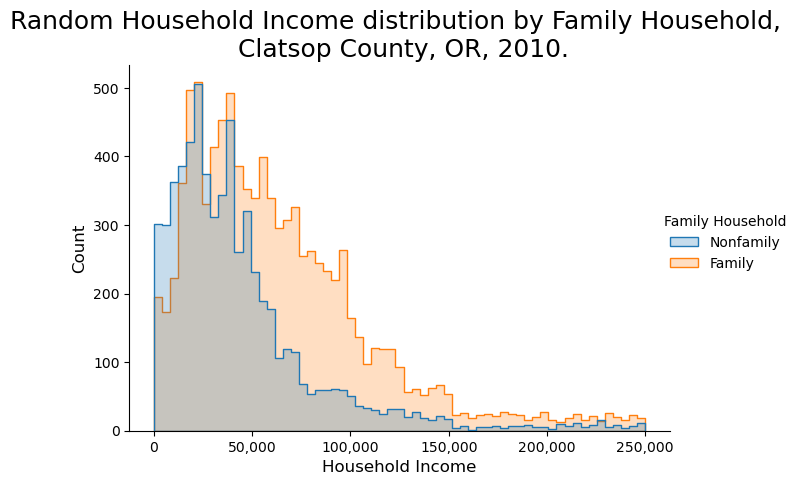

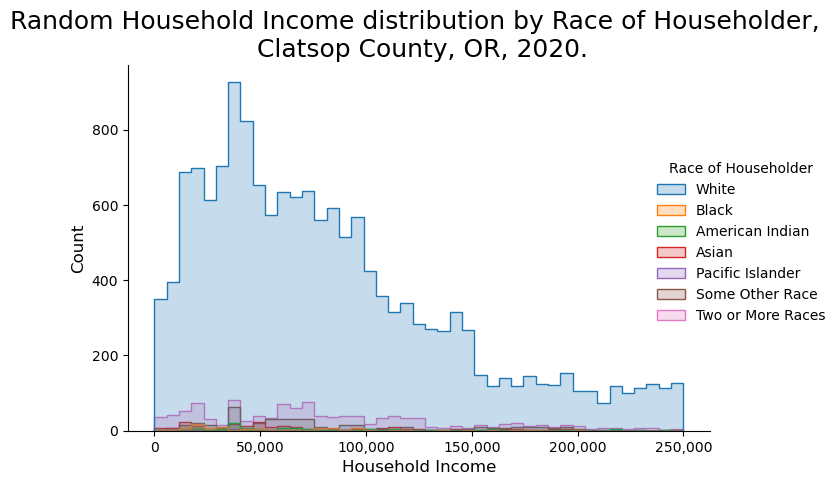

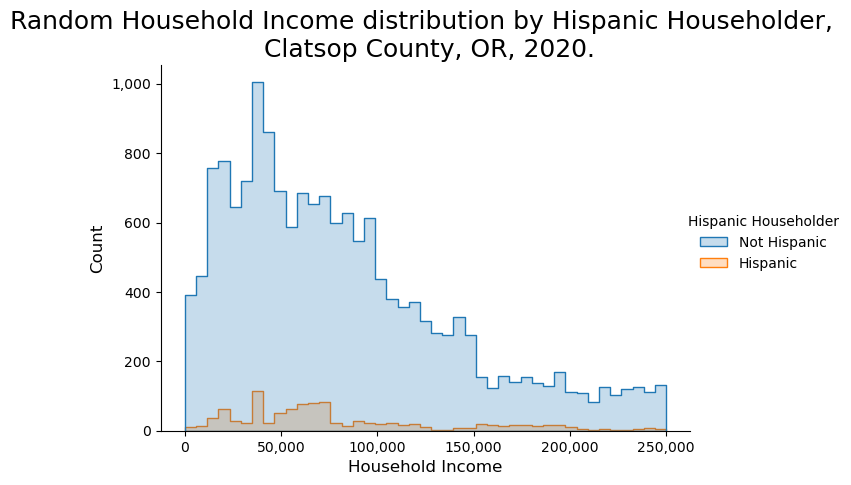

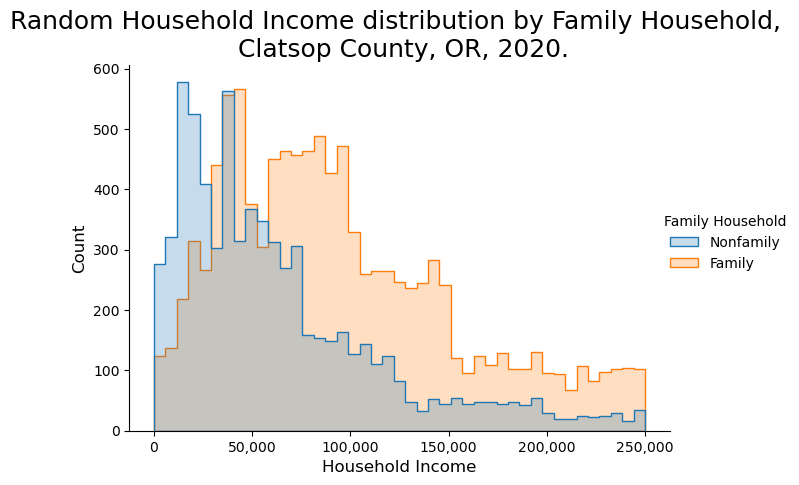

In [10]:
hua_hui_gdf_dict = {}
base_seed = 9876
iterations = 1
# iterate through basevintage options to run Monte Carlo Simulation
for basevintage in basevintage_options:
    hua_hui_gdf_dict[basevintage] = {}
    for i in range(iterations):
        seed_i = base_seed + i
        print(f"Running iteration {i+1} of {iterations} for basevintage {basevintage} with seed {seed_i}")
        workflow = process_community_workflow(
                    communities,
                    seed = seed_i,
                    version = '2.2.0',
                    version_text = 'v2-2-0',
                    basevintage = basevintage,
                    outputfolder ="OutputData",
                    outputfolders = {},
                    savefiles = True)
        hua_hui_gdf_dict[basevintage][seed_i] = workflow.process_communities()

## Explore and Validate Housing Unit Allocation


### Look at population characteristics and compare to US Census

In [11]:
focalplace = communities[community_id]['community_name']
print(focalplace, focalplace, countyname, countyfips)

Seaside, OR Seaside, OR Clatsop County, OR 41007


In [12]:
hua_gdf = hua_hui_gdf_dict['2010'][9876]

In [13]:
PopResultsTable.pop_results_table(
                  input_df = hua_gdf, 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2010 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied (%),2 Renter Occupied (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","21,017 (93.7%)","11,027 (81.6%)","32,044 (89.2%)"
"2 Black alone, Not Hispanic",55 (0.2%),42 (0.3%),97 (0.3%)
"3 American Indian and Alaska Native alone, Not Hispanic",136 (0.6%),149 (1.1%),285 (0.8%)
"4 Asian alone, Not Hispanic",248 (1.1%),92 (0.7%),340 (0.9%)
"5 Other Race, Not Hispanic",369 (1.6%),424 (3.1%),793 (2.2%)
"6 Any Race, Hispanic",607 (2.7%),"1,772 (13.1%)","2,379 (6.6%)"
Total,"22,432 (100.0%)","13,506 (100.0%)","35,938 (100.0%)"


In [14]:
PopResultsTable.pop_results_table(hua_gdf, 
                   who = "Median Household Income", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2010 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied,2 Renter Occupied,Median Household Income
Race Ethnicity,,,
"1 White alone, Not Hispanic","$46,632","$41,385","$44,816"
"2 Black alone, Not Hispanic","$60,424","$63,429","$62,730"
"3 American Indian and Alaska Native alone, Not Hispanic","$59,720","$51,319","$54,950"
"4 Asian alone, Not Hispanic","$36,911","$23,290","$24,926"
"5 Other Race, Not Hispanic","$38,240","$35,028","$35,808"
"6 Any Race, Hispanic","$33,102","$36,166","$35,926"
Total,"$46,229","$40,205","$43,884"


In [15]:
hua_gdf.head()

,huid,blockid,bgid,tractid,FIPScounty,numprec,ownershp,race,hispan,family,...,hhinc,randincome,poverty,BLOCKID10_str,fd_id_bid,placeNAME10,huestimate,x,y,geometry
0,B410079501001001H001,410079501001001,410079501001,41007950100,41007,1,1.0,1.0,0.0,0.0,...,3.0,35550.0,0.0,B410079501001001,nsi-17486242-84RR54QR+3WJ-17-17-17-19,Astoria,2.0,-123.857736,46.187723,POINT (-123.86 46.188)
1,B410079501001003H001,410079501001003,410079501001,41007950100,41007,1,2.0,1.0,0.0,0.0,...,3.0,36415.0,0.0,B410079501001003,nsi-17487660-84RR55Q2+P34-4-6-4-5,Astoria,7.0,-123.849789,46.189261,POINT (-123.85 46.189)
2,B410079501001003H002,410079501001003,410079501001,41007950100,41007,1,2.0,1.0,0.0,0.0,...,2.0,18058.0,0.0,B410079501001003,nsi-17487661-84RR54QX+HM3-7-6-6-6,Astoria,1.0,-123.850831,46.188893,POINT (-123.85 46.189)
3,B410079501001004H001,410079501001004,410079501001,41007950100,41007,1,2.0,1.0,0.0,0.0,...,2.0,16896.0,0.0,B410079501001004,nsi-17488311-84RR54QW+482-4-5-3-5,Astoria,7.0,-123.854229,46.187771,POINT (-123.85 46.188)
4,B410079501001004H002,410079501001004,410079501001,41007950100,41007,1,2.0,1.0,0.0,0.0,...,3.0,38897.0,0.0,B410079501001004,nsi-17488309-84RR54PW+R3G-6-6-5-7,Astoria,2.0,-123.854790,46.187075,POINT (-123.85 46.187)


In [16]:
# Show population counts by placeNAME10 - weight by numprec
hua_gdf.groupby('placeNAME10').size()

placeNAME10
Astoria            4993
Cannon Beach       1814
Gearhart           1450
Jeffers Gardens     160
Seaside            4643
Unincorporated     6154
Warrenton          2204
Westport            161
dtype: int64

In [17]:
focalplace

'Seaside, OR'

In [25]:
# set dataframe for focal place
focalplace_hua_gdf =  hua_gdf.loc[hua_gdf['placeNAME10'] == 'Seaside'].copy(deep=True)

In [26]:
PopResultsTable.pop_results_table(focalplace_hua_gdf, 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = focalplace,
                  when = '2010 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied (%),2 Renter Occupied (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","2,496 (89.1%)","2,841 (79.4%)","5,337 (83.6%)"
"2 Black alone, Not Hispanic",7 (0.2%),17 (0.5%),24 (0.4%)
"3 American Indian and Alaska Native alone, Not Hispanic",14 (0.5%),43 (1.2%),57 (0.9%)
"4 Asian alone, Not Hispanic",56 (2.0%),18 (0.5%),74 (1.2%)
"5 Other Race, Not Hispanic",46 (1.6%),103 (2.9%),149 (2.3%)
"6 Any Race, Hispanic",183 (6.5%),558 (15.6%),741 (11.6%)
Total,"2,802 (100.0%)","3,580 (100.0%)","6,382 (100.0%)"


In [27]:
PopResultsTable.pop_results_table(focalplace_hua_gdf, 
                   who = "Median Household Income", 
                  what = "by Race, Ethnicity",
                  where = focalplace,
                  when = '2010 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied,2 Renter Occupied,Median Household Income
Race Ethnicity,,,
"1 White alone, Not Hispanic","$44,072","$42,014","$43,057"
"2 Black alone, Not Hispanic","$69,398","$68,957","$69,178"
"3 American Indian and Alaska Native alone, Not Hispanic","$53,404","$52,295","$52,295"
"4 Asian alone, Not Hispanic","$37,118","$24,493","$36,749"
"5 Other Race, Not Hispanic","$70,410","$45,542","$47,277"
"6 Any Race, Hispanic","$37,337","$35,767","$36,464"
Total,"$43,477","$40,780","$42,175"


In [28]:
hua_gdf['fd_id_bid'].describe()

count                   21579
unique                  17735
top       missing building id
freq                      103
Name: fd_id_bid, dtype: object

In [29]:
bldg_uniqueid = 'fd_id_bid'
# add category for missing building id
buildingdata_conditions = {'cat_var' : {'variable_label' : 'Building Data Availability',
                         'notes' : 'Does Housing Unit have building data?'},
              'condition_list' : {
                1 : {'condition': f"(df['{bldg_uniqueid}'] == 'missing building id')", 'value_label': "0 Missing Building Data"},
                2 : {'condition': f"(df['{bldg_uniqueid}'] != 'missing building id')", 'value_label': "1 Building Data Available"}}
            }
hua_gdf = add_label_cat_conditions_df(hua_gdf, conditions = buildingdata_conditions)

0 Missing Building Data had 103 observations
1 Building Data Available had 21476 observations


In [30]:
PopResultsTable.pop_results_table(hua_gdf, 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = "2010",
                  row_index = "Race Ethnicity",
                  col_index = 'Building Data Availability_str',
                  row_percent = '0 Missing Building Data')

Building Data Availability_str,0 Missing Building Data (%),1 Building Data Available (%),Total Population by Households (%),Percent Row 0 Missing Building Data
Race Ethnicity,,,,
"1 White alone, Not Hispanic",132 (47.8%),"31,912 (87.1%)","32,044 (86.9%)",0.4%
"2 Black alone, Not Hispanic",nan (nan%),97 (0.3%),97 (0.3%),nan%
"3 American Indian and Alaska Native alone, Not Hispanic",nan (nan%),285 (0.8%),285 (0.8%),nan%
"4 Asian alone, Not Hispanic",4 (1.4%),336 (0.9%),340 (0.9%),1.2%
"5 Other Race, Not Hispanic",8 (2.9%),785 (2.1%),793 (2.1%),1.0%
"6 Any Race, Hispanic",5 (1.8%),"2,374 (6.5%)","2,379 (6.4%)",0.2%
7 Group Quarters no Race Ethnicity Data,127 (46.0%),829 (2.3%),956 (2.6%),13.3%
Total,276 (100.0%),"36,618 (100.0%)","36,894 (100.0%)",0.7%


In [31]:
focalplace_hua_gdf = add_label_cat_conditions_df(focalplace_hua_gdf, conditions = buildingdata_conditions)

PopResultsTable.pop_results_table(focalplace_hua_gdf, 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = focalplace,
                  when = "2010",
                  row_index = "Race Ethnicity",
                  col_index = 'Building Data Availability_str',
                  row_percent = '0 Missing Building Data')

0 Missing Building Data had 3 observations
1 Building Data Available had 4640 observations


Building Data Availability_str,0 Missing Building Data (%),1 Building Data Available (%),Total Population by Households (%),Percent Row 0 Missing Building Data
Race Ethnicity,,,,
"1 White alone, Not Hispanic",4 (44.4%),"5,333 (83.1%)","5,337 (83.0%)",0.1%
"2 Black alone, Not Hispanic",nan (nan%),24 (0.4%),24 (0.4%),nan%
"3 American Indian and Alaska Native alone, Not Hispanic",nan (nan%),57 (0.9%),57 (0.9%),nan%
"4 Asian alone, Not Hispanic",nan (nan%),74 (1.2%),74 (1.2%),nan%
"5 Other Race, Not Hispanic",nan (nan%),149 (2.3%),149 (2.3%),nan%
"6 Any Race, Hispanic",5 (55.6%),736 (11.5%),741 (11.5%),0.7%
7 Group Quarters no Race Ethnicity Data,nan (nan%),47 (0.7%),47 (0.7%),nan%
Total,9 (100.0%),"6,420 (100.0%)","6,429 (100.0%)",0.1%


In [32]:
PopResultsTable.pop_results_table(focalplace_hua_gdf, 
                  who = "Total Population by Households", 
                  what = "by Tenure Status",
                  where = focalplace,
                  when = "2010",
                  row_index = "Tenure Status",
                  col_index = 'Building Data Availability_str',
                  row_percent = '0 Missing Building Data')

Building Data Availability_str,0 Missing Building Data (%),1 Building Data Available (%),Total Population by Households (%),Percent Row 0 Missing Building Data
Tenure Status,,,,
1 Owner Occupied,4 (44.4%),"2,798 (43.9%)","2,802 (43.9%)",0.1%
2 Renter Occupied,5 (55.6%),"3,575 (56.1%)","3,580 (56.1%)",0.1%
Total,9 (100.0%),"6,373 (100.0%)","6,382 (100.0%)",0.1%


In [33]:
PopResultsTable.pop_results_table(focalplace_hua_gdf, 
                  who = "Total Population by Households", 
                  what = "by Income Groups",
                  where = focalplace,
                  when = "2010",
                  row_index = "Household Income Group",
                  col_index = 'Building Data Availability_str',
                  row_percent = '0 Missing Building Data')

Building Data Availability_str,0 Missing Building Data (%),1 Building Data Available (%),Total Population by Households (%),Percent Row 0 Missing Building Data
Household Income Group,,,,
"1 Less than $15,000",nan (nan%),691 (10.8%),691 (10.8%),nan%
"2 $15,000 to $24,999",nan (nan%),"1,108 (17.4%)","1,108 (17.4%)",nan%
"3 $25,000 to $74,999",nan (nan%),"3,027 (47.5%)","3,027 (47.4%)",nan%
"4 $75,000 to $99,999",4 (44.4%),654 (10.3%),658 (10.3%),0.6%
"5 $100,000 or more",5 (55.6%),893 (14.0%),898 (14.1%),0.6%
Total,9 (100.0%),"6,373 (100.0%)","6,382 (100.0%)",0.1%


#### Validate the Housing Unit Allocation has worked
Notice that the population count totals for the community
should match (pretty closely) data collected for the 2010 Decennial Census.
This can be confirmed by going to data.census.gov

In [34]:
print("Total Population by Race and Ethnicity:")
print(f"https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=DECENNIALSF12010.P5")

print("Median Income by Race and Ethnicity:")
print(f"All Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013")
print(f"Black Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013B")
print(f"White, not Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013H")
print(f"Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013I")

Total Population by Race and Ethnicity:
https://data.census.gov/cedsci/table?g=050XX00US41007&tid=DECENNIALSF12010.P5
Median Income by Race and Ethnicity:
All Households: https://data.census.gov/cedsci/table?g=050XX00US41007&tid=ACSDT5Y2012.B19013
Black Households: https://data.census.gov/cedsci/table?g=050XX00US41007&tid=ACSDT5Y2012.B19013B
White, not Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US41007&tid=ACSDT5Y2012.B19013H
Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US41007&tid=ACSDT5Y2012.B19013I


Differences in the housing unit allocation and the Census count may be due to differences between political boundaries and the building inventory. See Rosenheim et al 2019 for more details.

The housing unit allocation, plus the building results will become the input for the social science models such as the population dislocation model.